Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
&nbsp;&nbsp;&nbsp;&nbsp;http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.

# Use RankSEG in a MONAI post-processing pipeline

This tutorial demonstrates how to expose [RankSEG](https://github.com/rankseg/rankseg) as custom MONAI array and dictionary transforms and add it to a standard decollated post-processing pipeline. RankSEG is kept as an optional third-party dependency; no change to MONAI core is required.

The example runs inference on a real 3D CT volume from the Medical Segmentation Decathlon Task07 Pancreas dataset. It uses the official pretrained MONAI `pancreas_ct_dints_segmentation` Bundle and compares RankSEG with the usual `AsDiscrete(argmax=True)` decoder on exactly the same softmax probabilities. No model training or method-specific tuning is required.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Project-MONAI/tutorials/blob/main/modules/rankseg_integration.ipynb)

## What is RankSEG?

A segmentation network usually produces a score or probability for every class at every voxel. A conventional multiclass pipeline converts these values to a mask with `argmax`, independently assigning each voxel to the class with the largest score. This is a natural rule for voxel-wise classification, but it does not directly target region-level metrics such as Dice or IoU, whose values depend on the predicted region as a whole.

RankSEG is an inference-time, metric-aware alternative to argmax or fixed thresholding. It leaves the trained model and its probability maps unchanged, and only replaces the final probability-to-mask decision. Unlike connected-component filtering or morphological post-processing, RankSEG does not impose connectivity, shape, or anatomical constraints.

| Property | Argmax / fixed threshold | RankSEG |
| --- | --- | --- |
| Decision | Independent at each voxel | Based on each class probability map as a whole |
| Target | Voxel-wise class decision | A selected region metric, such as Dice or IoU |
| Region size | Implicit or controlled by a fixed threshold | Adaptively selected for each image and class |
| Model training | Unchanged | Unchanged |
| Additional inference cost | Minimal | Probability ranking and metric-aware optimization |

### How the algorithm works

For each class, RankSEG ranks voxels from highest to lowest predicted probability. The `RMA` solver used in this tutorial then estimates how many of the highest-ranked voxels should be included to target the selected metric. In multiclass mode, the class masks are finally combined into one non-overlapping label map. No model retraining or threshold tuning is required.

### When should RankSEG be considered?

RankSEG can be useful when Dice or IoU is the evaluation target and the model produces meaningful probability maps, particularly for uncertain predictions or small-to-medium foreground regions. When predictions are already confident, RankSEG and argmax may produce nearly identical masks.

RankSEG does not correct errors in the underlying probability maps, and its output depends on their quality and calibration. It also adds computation and memory use during inference because the probabilities must be ranked. Improvement is not guaranteed for every case or deployment distribution, so the metric, output mode, and solver should be selected deliberately and validated on representative data. The case below illustrates the integration rather than serving as a standalone performance benchmark.

## Setup environment

In [ ]:
%pip install -q --upgrade-strategy only-if-needed "monai-weekly[nibabel, tqdm,matplotlib]" "rankseg==0.0.5"
%matplotlib inline

## Setup imports

In [2]:
import hashlib
import os
import shutil
import tarfile
import tempfile
from collections.abc import Hashable, Mapping
from pathlib import Path
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
from monai.bundle import ConfigParser, download
from monai.config import print_config
from monai.data import decollate_batch
from monai.inferers import SlidingWindowInferer
from monai.metrics import DiceMetric
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    MapTransform,
    Orientationd,
    ScaleIntensityRanged,
    Spacingd,
    Transform,
)
from monai.utils import TransformBackends, convert_to_tensor
from monai.utils.type_conversion import convert_to_dst_type
from rankseg.functional import rankseg

print_config()

MONAI version: 1.7.dev2630


Numpy version: 2.2.6


Pytorch version: 2.13.0+cu130


MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 82bbaeeb45e5490606c4ff4615dd85e0e83fce7c
MONAI __file__: /home/<username>/rankseg/tutorials/.venv/lib/python3.10/site-packages/monai/__init__.py



Optional dependencies:


...

mlflow version: NOT INSTALLED or UNKNOWN VERSION.


pynrrd version: NOT INSTALLED or UNKNOWN VERSION.


clearml version: NOT INSTALLED or UNKNOWN VERSION.



For details about installing the optional dependencies, please visit:


    https://monai.readthedocs.io/en/latest/installation.html#installing-the-recommended-dependencies



## Bridge the MONAI and RankSEG shape conventions

MONAI post-processing transforms normally receive one decollated, channel-first sample with shape `(C, *spatial)`. The RankSEG functional API receives a batch of probability maps with shape `(B, C, *spatial)`. In multiclass mode it returns class-index maps with shape `(B, *spatial)`.

The array transform below adds a temporary batch dimension. Because that dimension has size one, the returned `(1, *spatial)` tensor already follows the same single-channel output convention as `AsDiscrete(argmax=True)`. `convert_to_dst_type` restores the source container type and MONAI metadata when applicable.

In [3]:
class RankSEG(Transform):
    """Decode a channel-first multiclass probability map with RankSEG."""

    backend = [TransformBackends.TORCH]

    def __init__(
        self,
        metric: str = "dice",
        solver: str = "RMA",
        pruning_prob: float = 0.5,
        **solver_params,
    ) -> None:
        self.metric = metric
        self.solver = solver
        self.pruning_prob = pruning_prob
        self.solver_params = solver_params

    def __call__(self, probabilities):
        source = probabilities
        probabilities = convert_to_tensor(probabilities, track_meta=False)
        if probabilities.ndim < 2:
            raise ValueError("probabilities must have shape (C, *spatial)")

        prediction = rankseg(
            probabilities.unsqueeze(0),
            metric=self.metric,
            solver=self.solver,
            output_mode="multiclass",
            pruning_prob=self.pruning_prob,
            **self.solver_params,
        )
        prediction, *_ = convert_to_dst_type(prediction, source, dtype=torch.float32)
        return prediction

## Setup data directory

Set `MONAI_DATA_DIRECTORY` to reuse the dataset and model Bundle across runs. Otherwise, this tutorial downloads them into a temporary directory and removes that directory at the end.

In [4]:
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print(root_dir)

/tmp/tmpj2w6asvp


## Download one MSD Pancreas validation case

Task07 Pancreas contains 3D abdominal CT volumes with pancreas and pancreatic tumor labels. The Medical Segmentation Decathlon data is distributed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). To combine first-party provenance with a small download, the helper below uses HTTP Range requests against a fixed version of [MONAI's official MSD archive](https://msd-for-monai.s3-us-west-2.amazonaws.com/Task07_Pancreas.tar). It fetches only the tar headers and contents for `pancreas_102` and its label (about 29.7 MB total), then verifies the member names, sizes, tar checksums, and SHA-256 digests.

In [5]:
case_id = "pancreas_102"
data_dir = Path(root_dir) / "Task07_Pancreas"
msd_archive_url = (
    "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task07_Pancreas.tar" "?versionId=lVhRU5n2ulILHz6suffqgfgJ__KFj.3q"
)
msd_archive_etag = '"7b7524e869b49821724aa61235443ae1-1466"'
# Each tuple is (relative path, tar-header offset, content size, SHA-256).
# These values are tied to the immutable S3 object version above.
msd_members = {
    "image": (
        f"imagesTr/{case_id}.nii.gz",
        8_795_902_464,
        29_648_519,
        "a57b50ac7d4a7053c46a801de99a17607e61d35970d1f2dc17738008690a395b",
    ),
    "label": (
        f"labelsTr/{case_id}.nii.gz",
        12_286_287_360,
        29_653,
        "63f3b90e305b07939bda0b8ae651934dadbaab5509a3c586d13e02a01be9bb49",
    ),
}


def fetch_archive_range(start, size):
    request = Request(
        msd_archive_url,
        headers={
            "Range": f"bytes={start}-{start + size - 1}",
            "If-Match": msd_archive_etag,
        },
    )
    with urlopen(request, timeout=120) as response:
        if response.status != 206:
            raise RuntimeError(f"unexpected HTTP status for range request: {response.status}")
        content = response.read(size + 1)
    if len(content) != size:
        raise RuntimeError(f"unexpected range size: expected {size}, received {len(content)}")
    return content


def download_msd_member(relative_path, header_offset, size, expected_sha256):
    output_path = data_dir / relative_path
    if output_path.exists():
        digest = hashlib.sha256(output_path.read_bytes()).hexdigest()
        if digest == expected_sha256:
            return str(output_path)

    # Parse the tar header to validate its checksum, name, size, and type.
    header = fetch_archive_range(header_offset, 512)
    member = tarfile.TarInfo.frombuf(header, encoding="utf-8", errors="surrogateescape")
    expected_name = f"Task07_Pancreas/{relative_path}"
    if member.name != expected_name or member.size != size or not member.isfile():
        raise RuntimeError(f"official MSD tar member metadata changed for {expected_name}")

    content = fetch_archive_range(header_offset + 512, size)
    if hashlib.sha256(content).hexdigest() != expected_sha256:
        raise RuntimeError(f"SHA-256 mismatch for {expected_name}")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_bytes(content)
    return str(output_path)


evaluation_file = {key: download_msd_member(*spec) for key, spec in msd_members.items()}

## Preprocess the real validation volume

This case belongs to the Bundle's fixed validation split. It was selected from a reproducible 20-case comparison because it makes the decoder change easy to see; the full comparison should be used for performance claims. The transforms reproduce the Bundle's inference preprocessing, with nearest-neighbor resampling added for the reference label.

In [6]:
validation_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="RAS", labels=None),
        Spacingd(
            keys=["image", "label"],
            pixdim=(1.0, 1.0, 1.0),
            mode=("bilinear", "nearest"),
        ),
        ScaleIntensityRanged(
            keys="image",
            a_min=-87,
            a_max=199,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
        EnsureTyped(keys=["image", "label"]),
    ]
)

evaluation_data = validation_transforms(evaluation_file)
print(f"image: {os.path.basename(evaluation_file['image'])}")
print(f"preprocessed shape: {tuple(evaluation_data['image'].shape)}")

image: pancreas_102.nii.gz
preprocessed shape: (1, 406, 406, 228)


## Load the pretrained MONAI Pancreas Bundle

The official [`pancreas_ct_dints_segmentation`](https://github.com/Project-MONAI/model-zoo/tree/dev/models/pancreas_ct_dints_segmentation) Bundle contains a three-class DiNTS model trained on MSD Task07. We use its architecture checkpoint and model weights without retraining or modification.

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
download(
    name="pancreas_ct_dints_segmentation",
    version="0.5.2",
    bundle_dir=root_dir,
)
bundle_dir = os.path.join(root_dir, "pancreas_ct_dints_segmentation")
architecture = torch.load(
    os.path.join(bundle_dir, "models", "search_code_18590.pt"),
    map_location=device,
    weights_only=False,
)
parser = ConfigParser()
parser.read_config(os.path.join(bundle_dir, "configs", "inference.yaml"))
parser["arch_ckpt"] = architecture
parser["dints_space#device"] = str(device)
model = parser.get_parsed_content("network_def").to(device)
checkpoint = torch.load(
    os.path.join(bundle_dir, "models", "model.pt"),
    map_location=device,
    weights_only=False,
)
model.load_state_dict(checkpoint.get("model", checkpoint))
model.eval()
print(f"inference device: {device}")

2026-07-31 16:36:13,766 - INFO - --- input summary of monai.bundle.scripts.download ---


2026-07-31 16:36:13,766 - INFO - > name: 'pancreas_ct_dints_segmentation'


2026-07-31 16:36:13,767 - INFO - > version: '0.5.2'


2026-07-31 16:36:13,767 - INFO - > bundle_dir: '/tmp/tmpj2w6asvp'


2026-07-31 16:36:13,767 - INFO - > source: 'monaihosting'


2026-07-31 16:36:13,767 - INFO - > remove_prefix: 'monai_'


2026-07-31 16:36:13,767 - INFO - > progress: True


2026-07-31 16:36:13,767 - INFO - ---




2026-07-31 16:36:26.295027 - Length of input patch is recommended to be a multiple of 32.


inference device: cuda:0


## Run sliding-window inference once

Inference produces one batched three-channel logit volume. Both decoders below receive exactly these logits; there is no retraining, threshold tuning, or method-specific preprocessing. A GPU is recommended, although the code also supports CPU execution with a smaller sliding-window batch.

In [8]:
input_volume = evaluation_data["image"].unsqueeze(0).to(device)
reference_volume = evaluation_data["label"].unsqueeze(0).to(device)
inferer = SlidingWindowInferer(
    roi_size=(96, 96, 96),
    sw_batch_size=2 if device.type == "cuda" else 1,
    overlap=0.625,
)

with torch.no_grad():
    logits = inferer(input_volume, model)

print(f"logits shape: {tuple(logits.shape)}")

logits shape: (1, 3, 406, 406, 228)


## Compare argmax and RankSEG post-processing

Both pipelines operate after `decollate_batch`, so the class dimension is dimension zero. Consequently, `Activations(softmax=True)` uses the correct default softmax dimension. If softmax is applied before decollation, its dimension should instead be set to the batched class dimension, normally `dim=1`.

In [9]:
post_argmax = Compose([Activations(softmax=True), AsDiscrete(argmax=True)])
post_rankseg = Compose([Activations(softmax=True), RankSEG(metric="dice")])

decollated_logits = decollate_batch(logits)
argmax_predictions = [post_argmax(item) for item in decollated_logits]
rankseg_predictions = [post_rankseg(item) for item in decollated_logits]

assert argmax_predictions[0].shape == rankseg_predictions[0].shape
print(f"argmax output shape: {tuple(argmax_predictions[0].shape)}")
print(f"RankSEG output shape: {tuple(rankseg_predictions[0].shape)}")

argmax output shape: (1, 406, 406, 228)
RankSEG output shape: (1, 406, 406, 228)


## Measure foreground Dice

Dice is measured on the same transformed reference volume used for both predictions. Background is excluded, and the pancreas and tumor scores are macro-averaged. This selected case is an integration example rather than a standalone benchmark.

In [10]:
to_one_hot = AsDiscrete(to_onehot=3)
reference_predictions = decollate_batch(reference_volume)
reference_one_hot = [to_one_hot(item) for item in reference_predictions]
argmax_one_hot = [to_one_hot(item) for item in argmax_predictions]
rankseg_one_hot = [to_one_hot(item) for item in rankseg_predictions]

dice_metric = DiceMetric(include_background=False, reduction="mean_batch")
dice_metric(y_pred=argmax_one_hot, y=reference_one_hot)
argmax_class_dice = dice_metric.aggregate()
dice_metric.reset()
dice_metric(y_pred=rankseg_one_hot, y=reference_one_hot)
rankseg_class_dice = dice_metric.aggregate()
dice_metric.reset()

argmax_dice = argmax_class_dice.mean().item()
rankseg_dice = rankseg_class_dice.mean().item()
print(f"Argmax macro Dice: {argmax_dice:.4f}")
print(f"RankSEG macro Dice: {rankseg_dice:.4f}")
print(f"Paired Dice change: {rankseg_dice - argmax_dice:+.4f}")
print(f"Pancreas Dice: {argmax_class_dice[0]:.4f} -> {rankseg_class_dice[0]:.4f}")
print(f"Tumor Dice: {argmax_class_dice[1]:.4f} -> {rankseg_class_dice[1]:.4f}")

Argmax macro Dice: 0.7747
RankSEG macro Dice: 0.8502
Paired Dice change: +0.0755
Pancreas Dice: 0.8764 -> 0.8898
Tumor Dice: 0.6730 -> 0.8106


## Visualize the real CT result

The axial slice is selected by maximum ground-truth tumor area, and the crop is based only on the ground-truth tumor bounds. The final panel highlights tumor-label decisions changed by RankSEG.

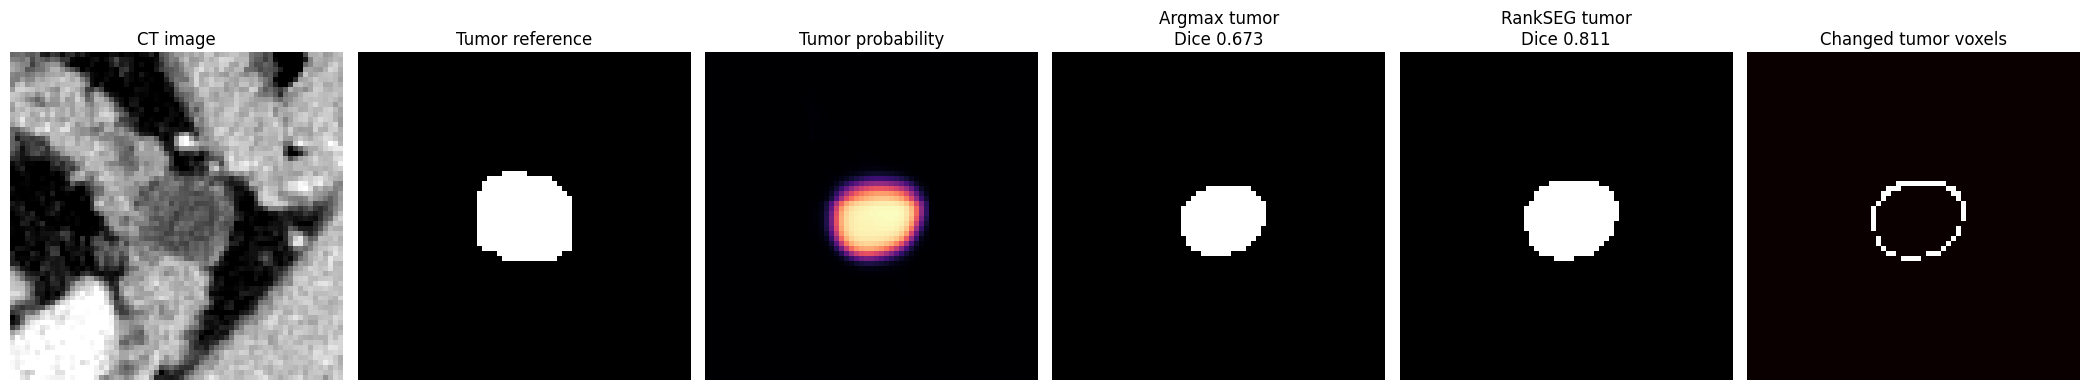

In [11]:
image = input_volume[0, 0].detach().cpu()
reference = reference_volume[0, 0].detach().cpu()
probabilities = torch.softmax(logits[0], dim=0).detach().cpu()
argmax_prediction = argmax_predictions[0][0].detach().cpu()
rankseg_prediction = rankseg_predictions[0][0].detach().cpu()
reference_tumor = reference == 2
argmax_tumor = argmax_prediction == 2
rankseg_tumor = rankseg_prediction == 2
slice_index = int(reference_tumor.sum(dim=(0, 1)).argmax().item())
coordinates = torch.nonzero(reference_tumor[:, :, slice_index], as_tuple=False)
margin = 24
row_start = max(0, int(coordinates[:, 0].min()) - margin)
row_end = min(reference.shape[0], int(coordinates[:, 0].max()) + margin + 1)
column_start = max(0, int(coordinates[:, 1].min()) - margin)
column_end = min(reference.shape[1], int(coordinates[:, 1].max()) + margin + 1)
decoder_difference = argmax_tumor != rankseg_tumor


def crop(panel):
    return panel[row_start:row_end, column_start:column_end, slice_index]


figure, axes = plt.subplots(1, 6, figsize=(21, 4))
panels = [
    (crop(image), "CT image", "gray"),
    (crop(reference_tumor), "Tumor reference", "gray"),
    (crop(probabilities[2]), "Tumor probability", "magma"),
    (crop(argmax_tumor), f"Argmax tumor\nDice {argmax_class_dice[1]:.3f}", "gray"),
    (crop(rankseg_tumor), f"RankSEG tumor\nDice {rankseg_class_dice[1]:.3f}", "gray"),
    (crop(decoder_difference), "Changed tumor voxels", "hot"),
]
for axis, (panel, title, color_map) in zip(axes, panels):
    axis.imshow(panel, cmap=color_map)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()

## Use RankSEGd in a dictionary post-processing pipeline

MONAI dictionary transforms inherit from `MapTransform`, copy the input mapping, and apply an array transform to the requested keys. `RankSEGd` therefore keeps the RankSEG-specific logic in `RankSEG` while fitting workflows in which predictions and metadata are carried under named keys.

In [12]:
class RankSEGd(MapTransform):
    """Dictionary wrapper for :class:`RankSEG`."""

    backend = RankSEG.backend

    def __init__(
        self,
        keys,
        metric: str = "dice",
        solver: str = "RMA",
        pruning_prob: float = 0.5,
        allow_missing_keys: bool = False,
        **solver_params,
    ) -> None:
        super().__init__(keys, allow_missing_keys)
        self.converter = RankSEG(
            metric=metric,
            solver=solver,
            pruning_prob=pruning_prob,
            **solver_params,
        )

    def __call__(self, data: Mapping[Hashable, object]) -> dict[Hashable, object]:
        output = dict(data)
        for key in self.key_iterator(output):
            output[key] = self.converter(output[key])
        return output


post_ranksegd = Compose(
    [
        Activationsd(keys="pred", softmax=True),
        RankSEGd(keys="pred", metric="dice"),
    ]
)

dictionary_samples = decollate_batch({"pred": logits})
dictionary_result = post_ranksegd(dictionary_samples[0])
torch.testing.assert_close(dictionary_result["pred"], rankseg_predictions[0])
print(f"dictionary output shape: {tuple(dictionary_result['pred'].shape)}")

dictionary output shape: (1, 406, 406, 228)


## Practical notes

- Use `metric="iou"` when IoU is the target metric.
- RankSEG expects finite probabilities in `[0, 1]`; apply softmax to multiclass logits or sigmoid to multilabel logits first.
- In the fixed 20-case comparison from which this case was selected, RankSEG (Dice) changed mean samplewise Dice by `+0.0209` and won on 18 of 20 cases. Use that paired evaluation, rather than this selected example alone, for performance claims.
- This wrapper intentionally demonstrates non-overlapping multiclass output. Multilabel RankSEG returns `(C, *spatial)` binary masks after removing the temporary batch dimension and needs slightly different shape handling.
- The Bundle and this tutorial are research examples and are not intended for diagnostic use.

Further reading:

- [RankSEG repository and documentation](https://github.com/rankseg/rankseg)
- [RankSEG: A Consistent Ranking-based Framework for Segmentation](https://www.jmlr.org/papers/v24/22-0712.html)
- [RankSEG-RMA: An Efficient Segmentation Algorithm via Reciprocal Moment Approximation](https://openreview.net/forum?id=4tRMm1JJhw)
- [Reproducible MONAI Pancreas comparison](https://github.com/rankseg/rankseg/tree/2f9e7e9e36145d960d3b568f340c4ccb60b397d4/experiments/monai-pr-8908-reproducibility)
- [MONAI Pancreas CT DiNTS Segmentation Bundle](https://github.com/Project-MONAI/model-zoo/tree/dev/models/pancreas_ct_dints_segmentation)
- [Discussion of Option B in MONAI PR #8908](https://github.com/Project-MONAI/MONAI/pull/8908#issuecomment-5077397523)

## Cleanup data directory

Remove downloaded data and model files only when a temporary directory was used.

In [13]:
if directory is None:
    shutil.rmtree(root_dir)